In [1]:
import os
import sys
import numpy as np
import pandas as pd
from scipy import stats
import shap

In [4]:
X = pd.read_pickle('../data/shap/fuzzy_x_20240106_values.pkl')
shap_values = np.load('../data/shap/fuzzy_xgb_20240106_shap_values.npy')
shap_interaction_values = np.load('../data/shap/fuzzy_xgb_20240106_shap_interaction_values.npy')

In [5]:
X = X.round(4)
shap_values = np.round(shap_values, 4)
shap_interaction_values = np.round(shap_interaction_values, 4)

In [6]:
variable_A_name = "I_12(mu)"
variable_A_index = X.columns.get_loc(variable_A_name)
variable_B_name = "Tipo P"
variable_B_index = X.columns.get_loc(variable_B_name)

In [7]:
from cgt_perezsechi.exploration.sampling import sample_size_kruskal_wallis

sample_size = sample_size_kruskal_wallis(X, shap_values, variable_A_name, acceleration=1)
if sample_size < len(X) / 10:
    sample_size = len(X) // 10

In [8]:
from cgt_perezsechi.manipulation.coding import code_interval

X_coded = code_interval(X, variable_A_name, sample_size)
df_A = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    'shap': shap_values[:, X.columns.get_loc(variable_A_name)]
})

In [9]:
df_B = pd.DataFrame({
    variable_B_name: X[variable_B_name],
    'shap': shap_values[:, X.columns.get_loc(variable_B_name)]
})

## Construcción de matrices de adyacencia

In [10]:
shap_interaction_values_A_B = shap_interaction_values[:, variable_A_index, variable_B_index]
df_interaction = pd.DataFrame({
    variable_A_name: X_coded[f'{variable_A_name}_interval'],
    variable_B_name: X_coded[variable_B_name],
    'shap_interaction': shap_interaction_values_A_B
})
df_interaction_grouped = df_interaction.groupby([variable_A_name, variable_B_name]).agg(["mean"]).reset_index()
df_interaction_grouped.columns = [variable_A_name, variable_B_name, 'shap_interaction']
df_interaction_grouped

,I_12(mu),Tipo P,shap_interaction
0,"[0.0,0.0192]",0,-0.026303
1,"[0.0,0.0192]",1,0.027172
2,"[0.0203,0.0611]",0,-0.022255
3,"[0.0203,0.0611]",1,0.022242
4,"[0.0612,0.1046]",0,-0.022152
5,"[0.0612,0.1046]",1,0.022210
6,"[0.1046,0.1531]",0,-0.020916
7,"[0.1046,0.1531]",1,0.020795
8,"[0.1532,0.1997]",0,-0.017347
9,"[0.1532,0.1997]",1,0.017432


In [11]:
unique_A_values = df_interaction_grouped[variable_A_name].unique()
unique_B_values = df_interaction_grouped[variable_B_name].unique()
variable_A_column_names = [f"{variable_A_name}_{value}" for value in unique_A_values]
variable_B_column_names = [f"{variable_B_name}_{value}" for value in unique_B_values]
column_names = variable_A_column_names + variable_B_column_names
r = pd.DataFrame(
    columns=column_names,
)

for A_value in unique_A_values:
    for B_value in unique_B_values:
        index_A = f"{variable_A_name}_{A_value}" 
        index_B = f"{variable_B_name}_{B_value}" 
        shap_interaction = df_interaction_grouped[
            (df_interaction_grouped[variable_A_name] == A_value) &
            (df_interaction_grouped[variable_B_name] == B_value)
        ]['shap_interaction'].values[0]
        r.loc[index_A, index_B] = shap_interaction
        r.loc[index_B, index_A] = shap_interaction

r.replace(np.nan, 0, inplace=True)
r_1 = r

/tmp/ipykernel_46090/2317974099.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  r.replace(np.nan, 0, inplace=True)


In [12]:
r_1

,"I_12(mu)_[0.0,0.0192]","I_12(mu)_[0.0203,0.0611]","I_12(mu)_[0.0612,0.1046]","I_12(mu)_[0.1046,0.1531]","I_12(mu)_[0.1532,0.1997]","I_12(mu)_[0.1998,0.2456]","I_12(mu)_[0.2456,0.2983]","I_12(mu)_[0.2994,0.3587]","I_12(mu)_[0.3595,0.4709]","I_12(mu)_[0.4727,0.934]",Tipo P_0,Tipo P_1
"I_12(mu)_[0.0,0.0192]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.026303,0.027172
Tipo P_0,-0.026303,-0.022255,-0.022152,-0.020916,-0.017347,-0.009389,-0.000895,0.007642,0.037298,0.089051,0.000000,0.000000
Tipo P_1,0.027172,0.022242,0.022210,0.020795,0.017432,0.008581,-0.000138,-0.012582,-0.041062,-0.091111,0.000000,0.000000
"I_12(mu)_[0.0203,0.0611]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.022255,0.022242
"I_12(mu)_[0.0612,0.1046]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.022152,0.022210
"I_12(mu)_[0.1046,0.1531]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.020916,0.020795
"I_12(mu)_[0.1532,0.1997]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.017347,0.017432
"I_12(mu)_[0.1998,0.2456]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.009389,0.008581
"I_12(mu)_[0.2456,0.2983]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.000895,-0.000138
"I_12(mu)_[0.2994,0.3587]",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007642,-0.012582


## Representación en grafo de la interacción entre valores de las variables "age" y "sex_isFemale"

In [13]:
df_A_stats = df_A.groupby(variable_A_name).agg(['mean']).reset_index()
df_A_stats.columns = [variable_A_name, 'shap']
df_B_stats = df_B.groupby(variable_B_name).agg(['mean']).reset_index()
df_B_stats.columns = [variable_B_name, 'shap']

In [14]:
df_A_stats

,I_12(mu),shap
0,"[0.0,0.0192]",0.172192
1,"[0.0203,0.0611]",0.155862
2,"[0.0612,0.1046]",0.159591
3,"[0.1046,0.1531]",0.037693
4,"[0.1532,0.1997]",-0.007359
5,"[0.1998,0.2456]",0.004298
6,"[0.2456,0.2983]",0.014807
7,"[0.2994,0.3587]",-0.029702
8,"[0.3595,0.4709]",-0.019209
9,"[0.4727,0.934]",0.184411


In [15]:
psi_1 = pd.DataFrame(
    columns=['value'],
)

for index, row in df_A_stats.iterrows():
    psi_1.loc[f'{variable_A_name}_{row[variable_A_name]}', 'value'] = row['shap']
for index, row in df_B_stats.iterrows():
    psi_1.loc[f'{variable_B_name}_{row[variable_B_name]:.0f}', 'value'] = row['shap']

psi_1.index.name = None
psi_1

,value
"I_12(mu)_[0.0,0.0192]",0.172192
"I_12(mu)_[0.0203,0.0611]",0.155862
"I_12(mu)_[0.0612,0.1046]",0.159591
"I_12(mu)_[0.1046,0.1531]",0.037693
"I_12(mu)_[0.1532,0.1997]",-0.007359
"I_12(mu)_[0.1998,0.2456]",0.004298
"I_12(mu)_[0.2456,0.2983]",0.014807
"I_12(mu)_[0.2994,0.3587]",-0.029702
"I_12(mu)_[0.3595,0.4709]",-0.019209
"I_12(mu)_[0.4727,0.934]",0.184411


In [16]:
from cgt_perezsechi.manipulation.norm import normalize_psi, normalize_r

psi_2 = normalize_psi(psi_1)
r_2 = normalize_r(r_1)

/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  max_edge_width = r.applymap(lambda x: abs(x)).max().max()
/home/secci/Localspace/UCM/thesis/thesis-python/.venv/lib/python3.10/site-packages/cgt_perezsechi/manipulation/norm.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  r = r.copy().applymap(lambda x: x / max_edge_width)


In [17]:
shap_cmap = shap.plots.colors.red_blue
positive_color = shap_cmap(1.0)[:3]
negative_color = shap_cmap(0.0)[:3]

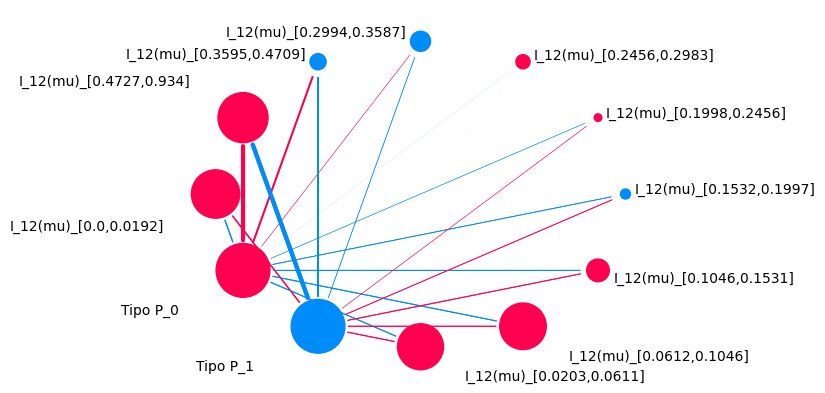

In [19]:
from cgt_perezsechi.visualization.graph import draw

positive_alpha = 0
negative_alpha = 0
positive_beta = 0
negative_beta = 0
draw(
    psi=psi_2,
    r=r_2,
    positive_alpha=positive_alpha,
    negative_alpha=negative_alpha,
    positive_beta=positive_beta,
    negative_beta=negative_beta,
    positive_color=positive_color,
    negative_color=negative_color,
    layout="shell",
    node_label_size_limit=5000
)